In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amineipad/titanic-dataset/train.csv
/kaggle/input/datasets/amineipad/titanic-dataset/test.csv


In [2]:
import numpy as np 
import pandas as pd 
df=pd.read_csv("/kaggle/input/datasets/amineipad/titanic-dataset/train.csv")

# **EDA**

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

# **Dropping The Columns**

In [8]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)
print("dropped")
print(df.shape)

dropped
(891, 8)


# **Fix Missing Values**

In [9]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna('S')
print("Missing Values Fixed")
print(df.isnull().sum())

Missing Values Fixed
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


# **Convert Object to Number**

In [10]:
df['Sex']=df['Sex'].map({'male': 0,'female':1})
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})
print("done miss")

done miss


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB
None


# **FIX OUTLIER**

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

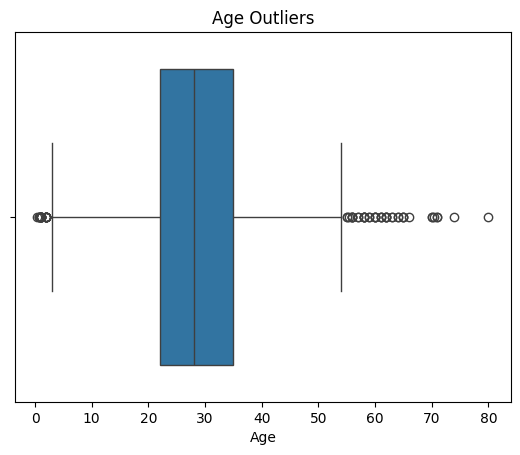

In [13]:
#checking age
sns.boxplot(x=df['Age'])
plt.title('Age Outliers')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

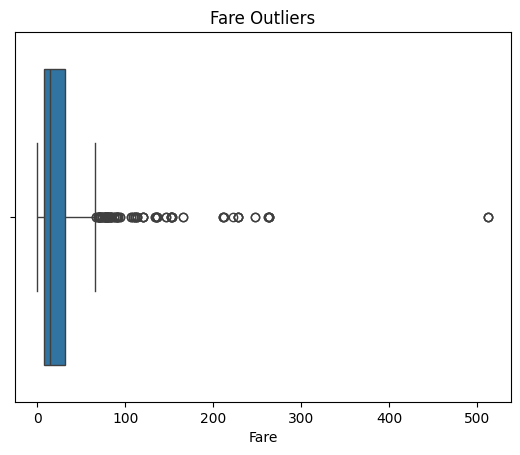

In [14]:
sns.boxplot(x=df['Fare'])
plt.title('Fare Outliers')
plt.show

# *Fare IQR*** 

In [15]:

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Fare Lower limit: {lower}")
print(f"Fare Upper limit: {upper}")

fare_outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(f"Fare outliers count: {len(fare_outliers)}")

Fare Lower limit: -26.724
Fare Upper limit: 65.6344
Fare outliers count: 116


as we know *Fare can never be negative* so fixing the fare outliers

In [16]:

df['Fare'] = df['Fare'].clip(upper=65.6344)

print("Fare outliers capped")
print(df['Fare'].max()) 

Fare outliers capped
65.6344


# **Age IQR**

In [17]:

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Age Lower limit: {lower}")
print(f"Age Upper limit: {upper}")

age_outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print(f"Age outliers count: {len(age_outliers)}")

Age Lower limit: 2.5
Age Upper limit: 54.5
Age outliers count: 66


The was in perfect rage so we are moving to some
# FEATURE ENGINEERING

**creating FamilySize**

In [18]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(df['FamilySize'].value_counts())

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


In [19]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df['IsAlone'].value_counts())

IsAlone
1    537
0    354
Name: count, dtype: int64


**Age Distribution**

In [20]:
df['AgeGroup'] = pd.cut(df['Age'],
                  bins=[0, 12, 18, 35, 60, 100],
                  labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

print(df['AgeGroup'].value_counts())

AgeGroup
Adult     535
Middle    195
Teen       70
Child      69
Senior     22
Name: count, dtype: int64


# **Visualisation**

**Survival Rate by Gender**

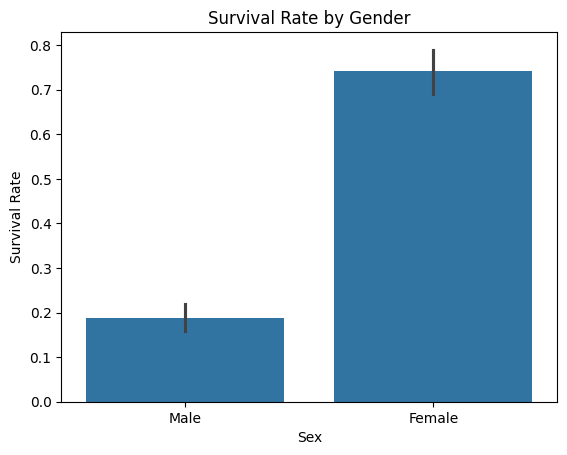

In [21]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.xticks([0, 1], ['Male', 'Female'])
plt.ylabel('Survival Rate')
plt.show()

**Age Distribution**

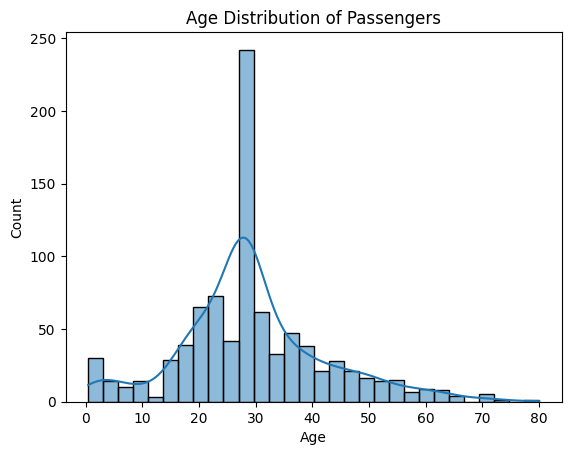

In [22]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Correlation Heatmap**

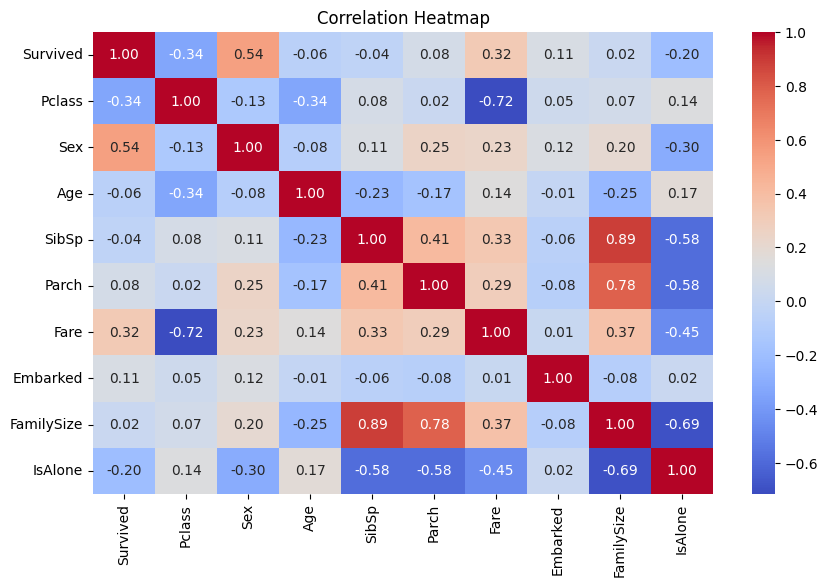

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()